# The same roof, with the yield computed instead of guessed

`pv_on_a_house.ipynb` states the yield: nine and a half thousand kilowatt-hours
a year, typed in from a rule of thumb.  Everything downstream was honest about
that, but the number itself was an assumption, and the roof's tilt and bearing
did nothing at all.

This notebook replaces that one assumption.  The weather comes from PVGIS, the
geometry goes through pvlib, and the yield falls out.  Nothing else changes —
which is the point: `Generation` is a seam, and swapping its implementation
leaves the appraisal untouched.

In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from simplyinvest import Term, Timeline, appraise
from simplyinvest.appraisal import Alternative
from simplyinvest.domain import GeometricDecline
from simplyinvest.financing import CashPurchase
from simplyinvest.pv import (
    EAST,
    GENERATED,
    MONTHLY_SHARE,
    SOUTH,
    WEST,
    Array,
    ClearSkyYear,
    DeclaredShare,
    Householder,
    Inverter,
    PvOperations,
    PvSupply,
    PvgisTmy,
    ResidentialExempt,
    SimulatedYield,
    Site,
    StatedYield,
    StaticPrice,
    System,
    cache_root,
)
from simplyinvest.pv.incentives import FeedInTariff
from simplyinvest.report import money_formatter, ranking_frame

SUN = "#b7791f"
GRID = "#2b6cb0"
SLATE = "#4a5568"

plt.rcParams.update(
    {
        "figure.figsize": (9.5, 4.2),
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.prop_cycle": plt.cycler(color=[SUN, GRID, SLATE]),
    }
)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

MONEY = money_formatter()
LIVE = date(2026, 9, 1)
AACHEN = Site(50.7753, 6.0839, altitude=180, name="Aachen")

## A year of weather, fetched once and kept

PVGIS builds a *typical meteorological year*: for each calendar month it picks
the most representative month out of many observed years and stitches the twelve
together.  It describes the shape of a year at this site, not a year that
happened.

The download is cached outside the project, beside a sidecar recording the
request, when it was fetched and what the service said about it.  A cached
figure nobody can attribute is a figure nobody can defend.

In [2]:
def weather_for(site):
    """The real typical year, or a cloudless one when the service is unreachable."""
    typical = PvgisTmy(site)
    try:
        typical.hourly()
    except Exception as unreachable:  # noqa: BLE001 - offline is not a failure here
        print(f"PVGIS unreachable ({type(unreachable).__name__}); "
              f"falling back to a cloudless year, which is a ceiling rather than a forecast.")
        return ClearSkyYear(site)
    return typical


weather = weather_for(AACHEN)
hours = weather.hourly()

print(weather.provenance)
print(f"cached under {cache_root() / 'weather'}")
display(hours[["ghi", "dni", "dhi", "temp_air", "wind_speed"]].describe().T[["mean", "max"]])

a typical year for Aachen from PVGIS, European Commission Joint Research Centre
cached under /home/phillipschlicht/.cache/simplyinvest/weather


,mean,max
ghi,118.25,922.00
dni,106.17,928.52
dhi,63.66,441.00
temp_air,9.66,32.71
wind_speed,3.24,10.90


## What the sun actually does over Aachen

Hour of the day against day of the year.  The envelope is the sun's geometry;
the texture inside it is weather.

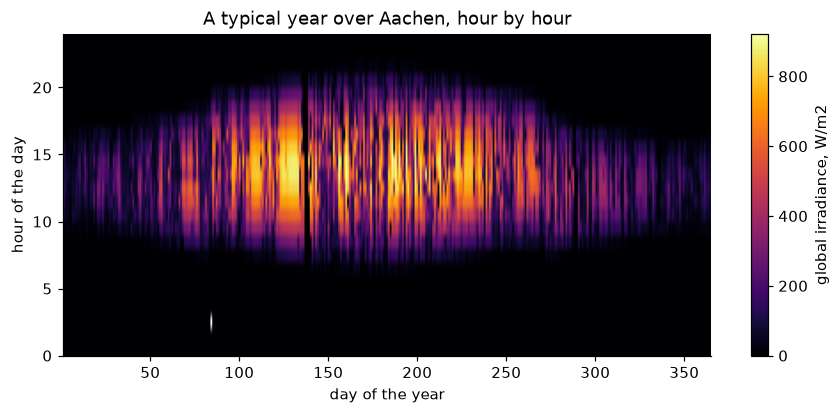

In [3]:
frame = hours.copy()
frame.index = pd.to_datetime(frame.index, utc=True).tz_convert("Europe/Berlin")
grid = frame["ghi"].groupby([frame.index.dayofyear, frame.index.hour]).mean().unstack()

fig, ax = plt.subplots(figsize=(9.5, 3.8))
shown = ax.imshow(
    grid.to_numpy().T, aspect="auto", origin="lower", cmap="inferno",
    extent=(1, 365, 0, 24),
)
fig.colorbar(shown, ax=ax, label="global irradiance, W/m2")
ax.set_xlabel("day of the year")
ax.set_ylabel("hour of the day")
ax.set_title("A typical year over Aachen, hour by hour")
ax.grid(visible=False)
plt.show()

## Which way should the roof face?

This is the question the stated path could not ask at all, because tilt and
bearing did nothing in it.

South maximises the kilowatt-hours.  East–west gives up some of them for a
broader production curve — and a broader curve is worth more per kilowatt-hour
when it matches a household's morning and evening load.  The second half of that
trade needs an hourly load profile, which is the next milestone; for now the
chart shows what the first half costs.

The June dip in the right-hand chart is not an error.  A typical year is
stitched together from twelve different observed years, so neighbouring months
need not sit on a smooth curve — the June that was picked as representative was
a cloudy one.

,kWh a year,kWh per kWp,against south
"south, 30 deg","9,542.07",954.21,0.00
"south, 15 deg","9,073.05",907.31,-0.05
"east-west, 15 deg","8,073.25",807.32,-0.15
flat,"8,150.55",815.06,-0.15


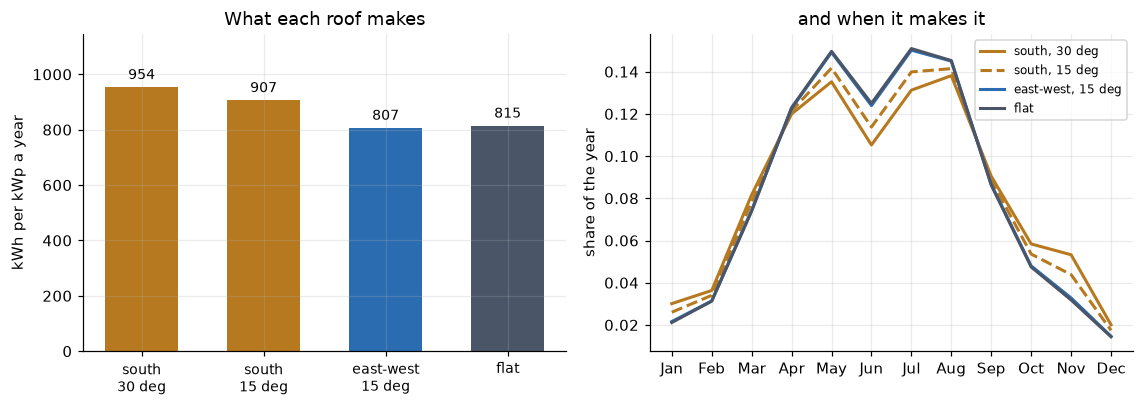

In [4]:
roofs = {
    "south, 30 deg": (Array(10.0, tilt=30, azimuth=SOUTH),),
    "south, 15 deg": (Array(10.0, tilt=15, azimuth=SOUTH),),
    "east-west, 15 deg": (Array(5.0, tilt=15, azimuth=EAST), Array(5.0, tilt=15, azimuth=WEST)),
    "flat": (Array(10.0, tilt=0, azimuth=SOUTH),),
}
yields = {name: SimulatedYield(AACHEN, arrays, weather) for name, arrays in roofs.items()}

shape = pd.DataFrame(
    {name: made.monthly_share for name, made in yields.items()},
    index=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
           "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
)
totals = pd.Series({name: float(made.first_year_kwh) for name, made in yields.items()})
display(
    pd.DataFrame({
        "kWh a year": totals,
        "kWh per kWp": totals / 10.0,
        "against south": totals / totals["south, 30 deg"] - 1.0,
    })
)

fig, (left, right) = plt.subplots(1, 2, figsize=(10.5, 3.8))
bars = left.bar(range(len(totals)), totals.to_numpy() / 10.0,
                color=[SUN, SUN, GRID, SLATE], width=0.6)
left.bar_label(bars, fmt=lambda v: f"{v:,.0f}", padding=3, fontsize=9)
left.set_xticks(range(len(totals)), [n.replace(", ", "\n") for n in totals.index], fontsize=9)
left.set_ylabel("kWh per kWp a year")
left.set_ylim(0, totals.max() / 10.0 * 1.2)
left.set_title("What each roof makes")

for name, colour in zip(shape.columns, [SUN, SUN, GRID, SLATE], strict=True):
    right.plot(shape.index, shape[name], color=colour, linewidth=2,
               linestyle="--" if name == "south, 15 deg" else "-", label=name)
right.set_ylabel("share of the year")
right.set_title("and when it makes it")
right.legend(fontsize=8)
plt.tight_layout()
plt.show()

## How good was the rule of thumb?

The stated notebook typed in 9,500 kWh a year and a seasonal shape I wrote from
general knowledge of German output.  Both can now be checked against the roof
they were meant to describe.

stated:    9,500 kWh a year
simulated: 9,542 kWh a year
the guess was out by -0.4%


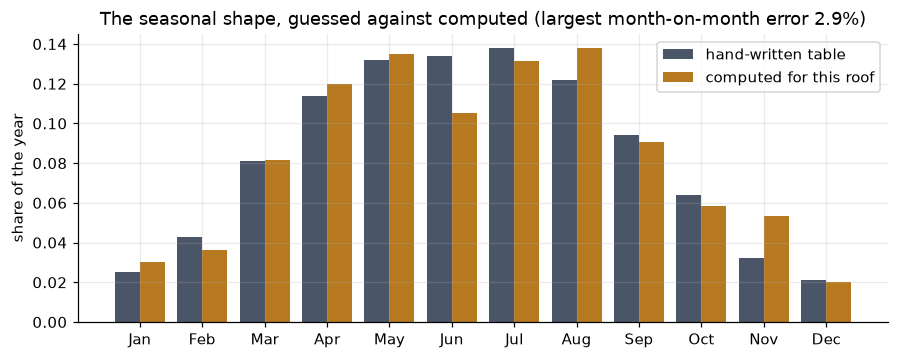

In [5]:
simulated = yields["south, 30 deg"]
guessed = StatedYield(9_500.0)

hand = np.asarray(MONTHLY_SHARE) / np.sum(MONTHLY_SHARE)
computed = np.asarray(simulated.monthly_share)

print(f"stated:    9,500 kWh a year")
print(f"simulated: {float(simulated.first_year_kwh):,.0f} kWh a year")
print(f"the guess was out by {9_500 / float(simulated.first_year_kwh) - 1:+.1%}")

fig, ax = plt.subplots(figsize=(9.5, 3.4))
months = np.arange(12)
ax.bar(months - 0.2, hand, width=0.4, color=SLATE, label="hand-written table")
ax.bar(months + 0.2, computed, width=0.4, color=SUN, label="computed for this roof")
ax.set_xticks(months, shape.index)
ax.set_ylabel("share of the year")
ax.set_title(
    f"The seasonal shape, guessed against computed "
    f"(largest month-on-month error {np.abs(hand - computed).max():.1%})"
)
ax.legend()
plt.show()

## Into the appraisal, with nothing else changed

`SimulatedYield` and `StatedYield` are two implementations of one protocol, so
the system, the household, the tariff and the whole cash-flow machinery are
untouched.  Only the object handed to `PvSupply` is different.

In [6]:
system = System(
    name="10 kWp, south",
    price=14_500.0,
    peak_kw=10.0,
    residual=GeometricDecline(0.06),
    inverter=Inverter(replacement_cost=1_600.0),
    commissioning=LIVE,
    connection_cost=500.0,
    service_cost=120.0,
    insurance=90.0,
    metering_cost=60.0,
)
owner = Householder(retail_price=StaticPrice(0.34), annual_consumption_kwh=4_200.0)
timeline = Timeline(
    Term.of_years(25),
    periods_per_year=12,
    rate=0.03,
    start_date=LIVE,
    escalations={"electricity": 0.03, "operating_cost": 0.02},
)
plan = Alternative(
    system.name,
    sources=(CashPurchase().bind(system), PvOperations(system), FeedInTariff().bind(system)),
    tax=ResidentialExempt(),
)

answers = {}
for label, generation in (("stated 9,500 kWh", guessed), ("simulated", simulated)):
    supply = PvSupply(generation, DeclaredShare(0.30))
    answers[label] = appraise(plan, timeline, party=owner, usage=supply)

display(
    pd.DataFrame(
        {
            label: {
                "yield, first year (kWh)": PvSupply(g, DeclaredShare(0.30)).annual(GENERATED),
                "net present value": float(result.npv),
                "cost per kWh generated": result.cost_per_unit(GENERATED),
            }
            for (label, result), g in zip(answers.items(), (guessed, simulated), strict=True)
        }
    )
)

,"stated 9,500 kWh",simulated
"yield, first year (kWh)","9,500.00","9,542.07"
net present value,"8,968.67","9,107.00"
cost per kWh generated,0.10,0.10


## And what the roof choice is worth

Same household, same tariff, same twenty-five years — only the geometry moves.

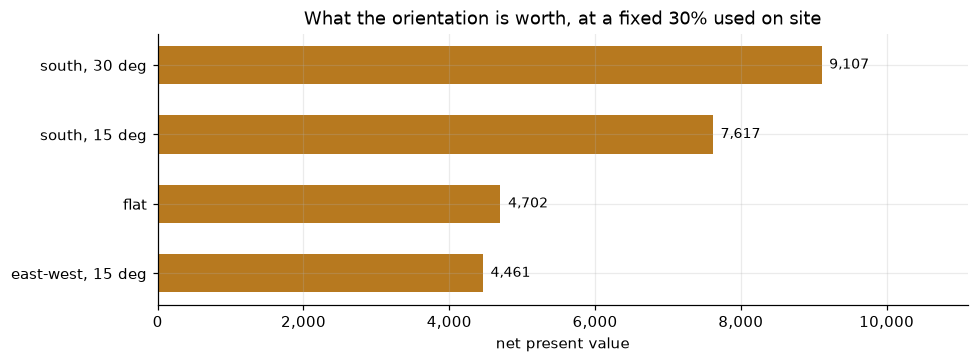

the best and worst roof are 4,646 apart over twenty-five years.

Held fixed here: the self-consumption share.  East-west would in reality
hold a larger share than south, which is exactly what a dispatched load
profile computes - and what this model cannot yet tell you.


In [7]:
by_roof = {}
for name, made in yields.items():
    supply = PvSupply(made, DeclaredShare(0.30))
    by_roof[name] = float(appraise(plan, timeline, party=owner, usage=supply).npv)

ranked = pd.Series(by_roof).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9.5, 3.2))
bars = ax.barh(list(ranked.index), ranked.to_numpy(), color=SUN, height=0.55)
ax.bar_label(bars, fmt=lambda v: f"{v:,.0f}", padding=5, fontsize=9)
ax.set_xlim(0, ranked.max() * 1.22)
ax.xaxis.set_major_formatter(MONEY)
ax.set_xlabel("net present value")
ax.set_title("What the orientation is worth, at a fixed 30% used on site")
ax.invert_yaxis()
plt.show()

spread = ranked.max() - ranked.min()
print(f"the best and worst roof are {spread:,.0f} apart over twenty-five years.")
print()
print("Held fixed here: the self-consumption share.  East-west would in reality")
print("hold a larger share than south, which is exactly what a dispatched load")
print("profile computes - and what this model cannot yet tell you.")

## What this does and does not now assume

The yield is no longer a guess.  Everything else still is — and the one that
matters most, the self-consumption share, is still stated rather than simulated.

In [8]:
result = answers["simulated"]
print(f"weather: {weather.provenance}\n")
for note in result.constraints:
    print(f"- {note}\n")

weather: a typical year for Aachen from PVGIS, European Commission Joint Research Centre

- Self-consumption is valued at the working price alone.  The standing charge is owed whatever the roof does, so it is not avoided.

- The roof is assumed to carry the array for the whole horizon; stripping and refitting it for a re-roof is not priced.

- This implies about 2,697 kWh a year used on site.  Check that against a bill before trusting the result.

- No storage is fitted, so everything generated outside the hours it is used is exported.

- The tariff is fixed in money of the day for the whole term, so it buys less every year.  The retail price it is compared against does not.

- These figures assume EStG §3 Nr. 72 applies: the system is at most 30 kWp on a dwelling, and the operator stays under the 100 kWp cap across everything they own.  Above either limit the feed-in revenue is taxable and this appraisal understates the cost.

